EDA    Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import files
import pandas as pd
import io

print("Please upload your 'SampleSuperstore.csv' file:")
uploaded = files.upload()

# Once uploaded, we can read it into a DataFrame
for filename in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f'\nSuccessfully loaded: {filename}')
    display(df.head(2))

Please upload your 'SampleSuperstore.csv' file:


Saving SampleSuperstore.csv to SampleSuperstore.csv

Successfully loaded: SampleSuperstore.csv


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.0,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.0,219.5820


INSPECTING THE DATA

### Common Methods to Inspect Data

1. **`df.head()`**: Displays the first 5 rows (useful for a quick preview).
2. **`df.tail()`**: Displays the last 5 rows.
3. **`df.info()`**: Shows column names, data types, and non-null counts (memory usage).
4. **`df.describe()`**: Provides statistical summary (mean, std, min, max, etc.) for numerical columns.
5. **`df.shape`**: Returns a tuple representing the dimensionality (rows, columns).
6. **`df.columns`**: Lists all column names.
7. **`df.isnull().sum()`**: Checks for missing values in each column.

In [3]:
df.info()  # it gives the details of various columns and it's types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [4]:
df.shape # tells the dimensions of the table

(9994, 13)

In [5]:
df.describe().round(2)

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00
mean,55190.38,229.86,3.79,0.16,28.66
std,32063.69,623.25,2.23,0.21,234.26
min,1040.00,0.44,1.00,0.00,-6599.98
25%,23223.00,17.28,2.00,0.00,1.73
50%,56430.50,54.49,3.00,0.20,8.67
75%,90008.00,209.94,5.00,0.20,29.36
max,99301.00,22638.48,14.00,0.80,8399.98


CHECKING FOR NULL VALUES

In [6]:
# Check for missing values
print("Missing values per column:")
display(df.isnull().sum())



Missing values per column:


,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


Zero null values
 the dataset is structurally complete. No imputation needed.

SINCE WE FOUND NO NULL VALUES, NEXT STEP IS DATA CLEANING I.E., REMOVING DUPLICATES

In [7]:
# 1. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If there are duplicates, we can drop them
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")



Number of duplicate rows: 17
Duplicates removed.


No duplicate rows detected. Dataset is clean at the structural level.


In [8]:
df['Sales'].unique()

array([261.96 , 731.94 ,  14.62 , ..., 437.472,  97.98 , 243.16 ])

In [9]:
df1 = df.copy()


'Postal Code' re-cast to zero-padded string.
Made a copy of original dataset to preserve it from miscellinious changes.

In [10]:
df1.drop(columns=['Postal Code'], inplace=True)

/tmp/ipykernel_2164/3889664338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette=palettes[i % len(palettes)], legend=False) # Use df consistently for plotting


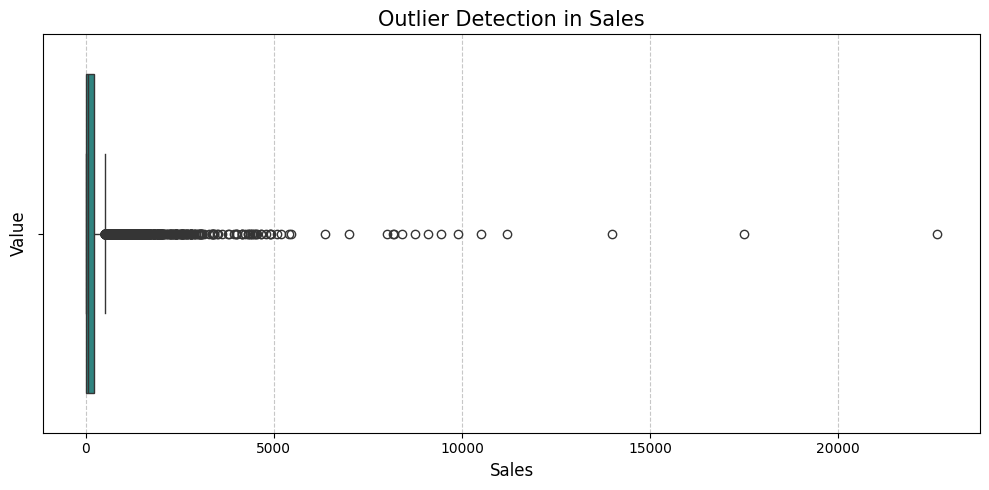

Summary Statistics for Sales:


,Sales
count,9977.000000
mean,230.148902
std,623.721409
min,0.444000
25%,17.300000
50%,54.816000
75%,209.970000
max,22638.480000


/tmp/ipykernel_2164/3889664338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette=palettes[i % len(palettes)], legend=False) # Use df consistently for plotting



--------------------------------------------------



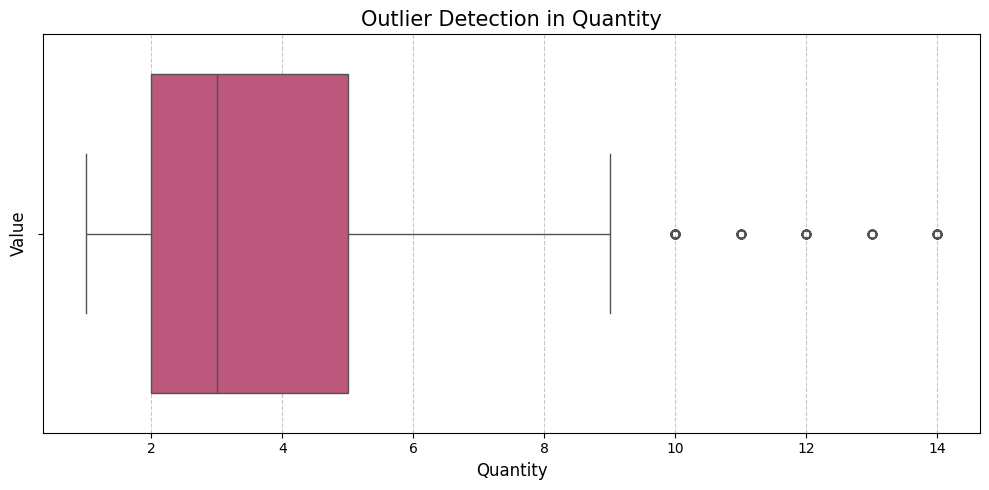

Summary Statistics for Quantity:


,Quantity
count,9977.000000
mean,3.790719
std,2.226657
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,14.000000



--------------------------------------------------



/tmp/ipykernel_2164/3889664338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette=palettes[i % len(palettes)], legend=False) # Use df consistently for plotting


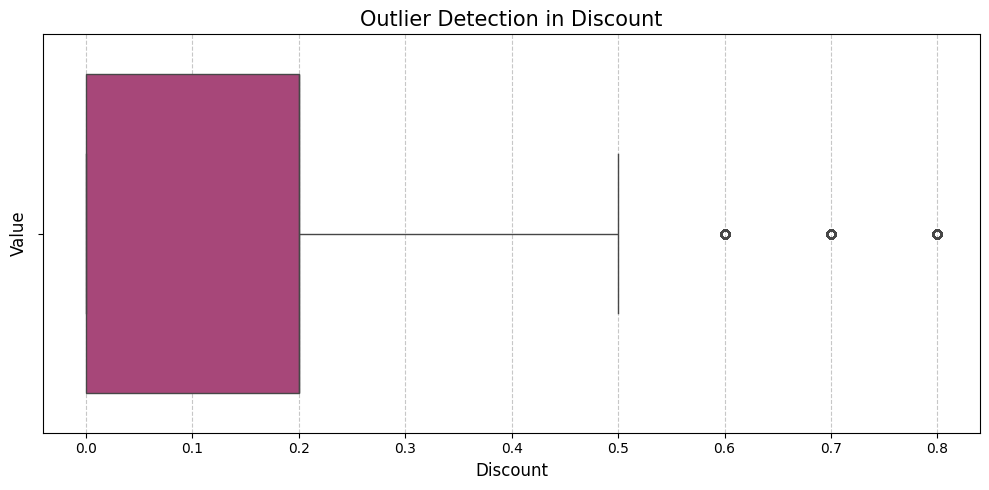

Summary Statistics for Discount:


,Discount
count,9977.000000
mean,0.156278
std,0.206455
min,0.000000
25%,0.000000
50%,0.200000
75%,0.200000
max,0.800000



--------------------------------------------------



/tmp/ipykernel_2164/3889664338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette=palettes[i % len(palettes)], legend=False) # Use df consistently for plotting


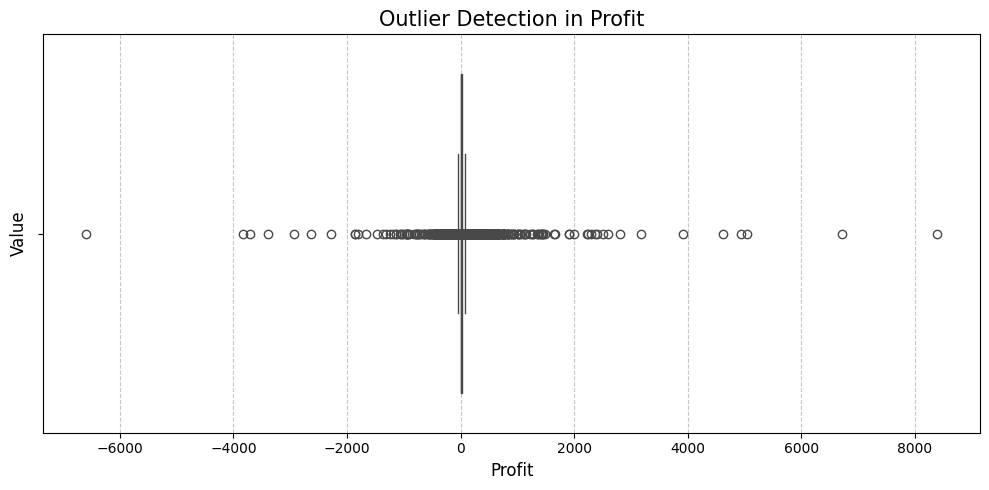

Summary Statistics for Profit:


,Profit
count,9977.00000
mean,28.69013
std,234.45784
min,-6599.97800
25%,1.72620
50%,8.67100
75%,29.37200
max,8399.97600



--------------------------------------------------



In [14]:
# List of columns to check for outliers
outlier_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
# Define a list of palettes for attractive visualizations
palettes = ['viridis', 'plasma', 'magma', 'cividis']

for i, col in enumerate(outlier_cols):
    plt.figure(figsize=(10, 5))
    # Cycle through different palettes for each box plot
    sns.boxplot(x=df[col], palette=palettes[i % len(palettes)], legend=False) # Use df consistently for plotting
    plt.title(f'Outlier Detection in {col}', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Value', fontsize=12) # Add a y-label for clarity
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a grid for readability
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

    print(f"Summary Statistics for {col}:")
    display(df[col].describe()) # Using df for consistency
    print("\n" + "-"*50 + "\n")

Sales: 1167 outliers
Quantity: 170 outliers
Discount: 855 outliers
Profit: 1881 outliers




Profit has significant outliers on both ends
 massive profits on tech orders, deep losses on discounted furniture.
DECISION: Outliers RETAINED  they are real business transactions, not data entry errors.
Removing them would mask the exact problem (deep discounts causing losses) we need to expose.


### Univariate Analysis of Sales

Understanding the distribution of 'Sales' is crucial for a business. It can reveal typical transaction values, identify high-value sales events, and show the overall range of revenue generated per transaction. We will visualize both the raw sales data and its log-transformed version to better understand its underlying patterns.

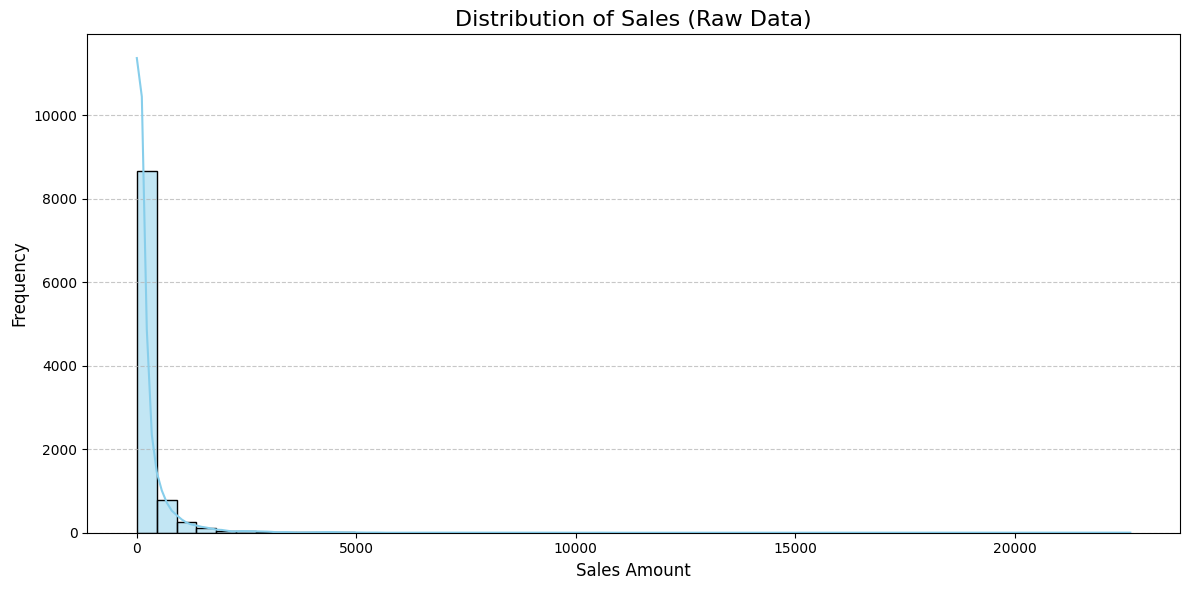

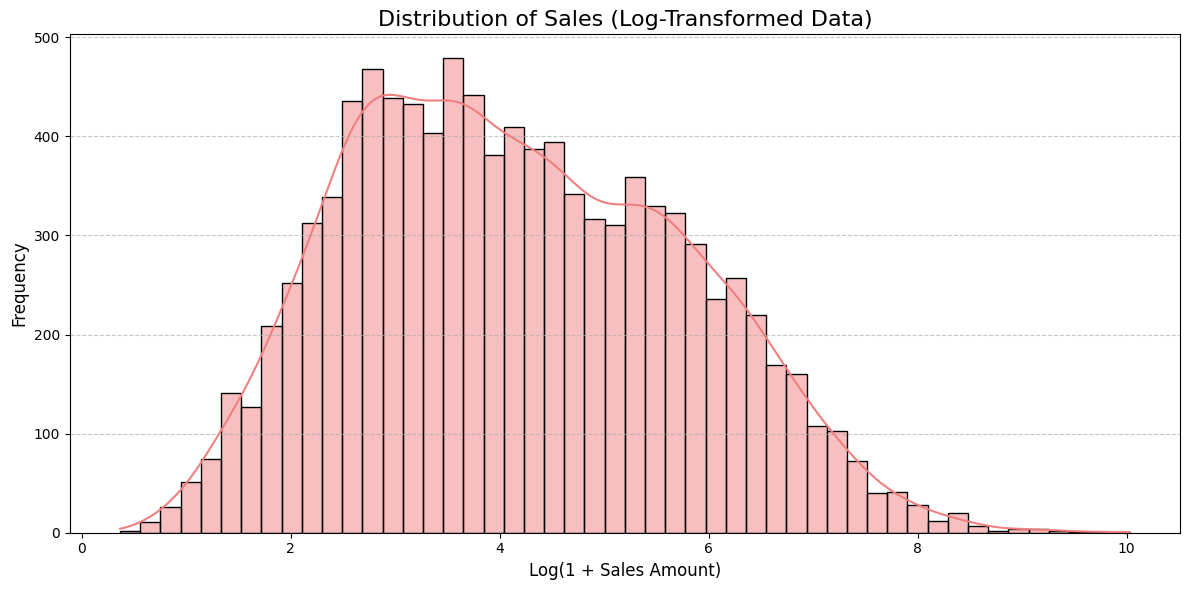

In [15]:

plt.figure(figsize=(12, 6))
sns.histplot(df['Sales'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Sales (Raw Data)', fontsize=16)
plt.xlabel('Sales Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting the histogram for log-transformed 'Sales'
# Using np.log1p to handle potential zero values gracefully (log(1+x))
df['Log_Sales'] = np.log1p(df['Sales'])

plt.figure(figsize=(12, 6))
sns.histplot(df['Log_Sales'], bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Sales (Log-Transformed Data)', fontsize=16)
plt.xlabel('Log(1 + Sales Amount)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary of Sales Distribution Analysis

**Raw Sales Distribution:**
The histogram of raw 'Sales' data typically shows a heavily right-skewed distribution. This implies that most sales transactions are of smaller values, with a long tail extending towards higher sales amounts, indicating a few very large transactions. In business terms, this means:
*   **High Volume, Low Value:** The majority of transactions contribute a smaller amount individually to the total revenue.
*   **Key Customers/Products:** The few high-value sales represent significant revenue drivers, possibly from key customers, large orders, or high-priced products/services. These outliers, while few, are crucial for overall profitability and warrant separate attention.


**Log-Transformed Sales Distribution:**
After applying a log transformation (specifically `np.log1p`), the distribution of 'Sales' often becomes more symmetrical, resembling a normal distribution. This transformation helps in:

*   **Mitigating Outlier Impact:** It reduces the disproportionate influence of extreme high-value sales (outliers) on statistical analyses, providing a clearer picture of the central tendency.


In [16]:
# 1. Profit Margin
# Profit Margin = (Total Profit / Total Sales) * 100
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_profit_margin = (total_profit / total_sales) * 100

# 2. Loss Percentage
# Loss Percentage = (Number of orders with negative profit / Total number of orders) * 100
loss_orders = df[df['Profit'] < 0]
loss_percentage = (len(loss_orders) / len(df)) * 100

print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")
print(f"Loss Percentage (Frequency of unprofitable orders): {loss_percentage:.2f}%")

# Quick breakdown of average loss vs average profit for insight
avg_profit = df[df['Profit'] >= 0]['Profit'].mean()
avg_loss = df[df['Profit'] < 0]['Profit'].mean()

print(f"\nAverage Profit per winning order: ${avg_profit:.2f}")
print(f"Average Loss per losing order: ${avg_loss:.2f}")

Overall Profit Margin: 12.47%
Loss Percentage (Frequency of unprofitable orders): 18.73%

Average Profit per winning order: $54.56
Average Loss per losing order: $-83.53


### Univariate Analysis of Profit

Analyzing 'Profit' helps identify the typical earnings per transaction and the extent of losses. Since profit contains negative values, we will visualize the raw distribution and a shifted log-transformation to better observe the spread of both gains and losses.

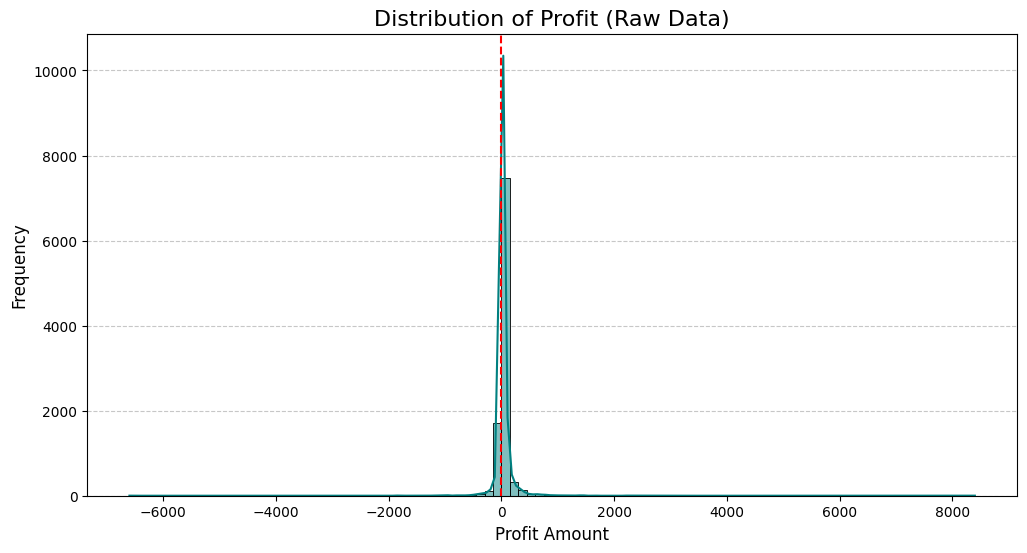

In [17]:

plt.figure(figsize=(12, 6))
sns.histplot(df['Profit'], bins=100, kde=True, color='teal')
plt.title('Distribution of Profit (Raw Data)', fontsize=16)
plt.xlabel('Profit Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(0, color='red', linestyle='--') # Mark the zero profit line
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



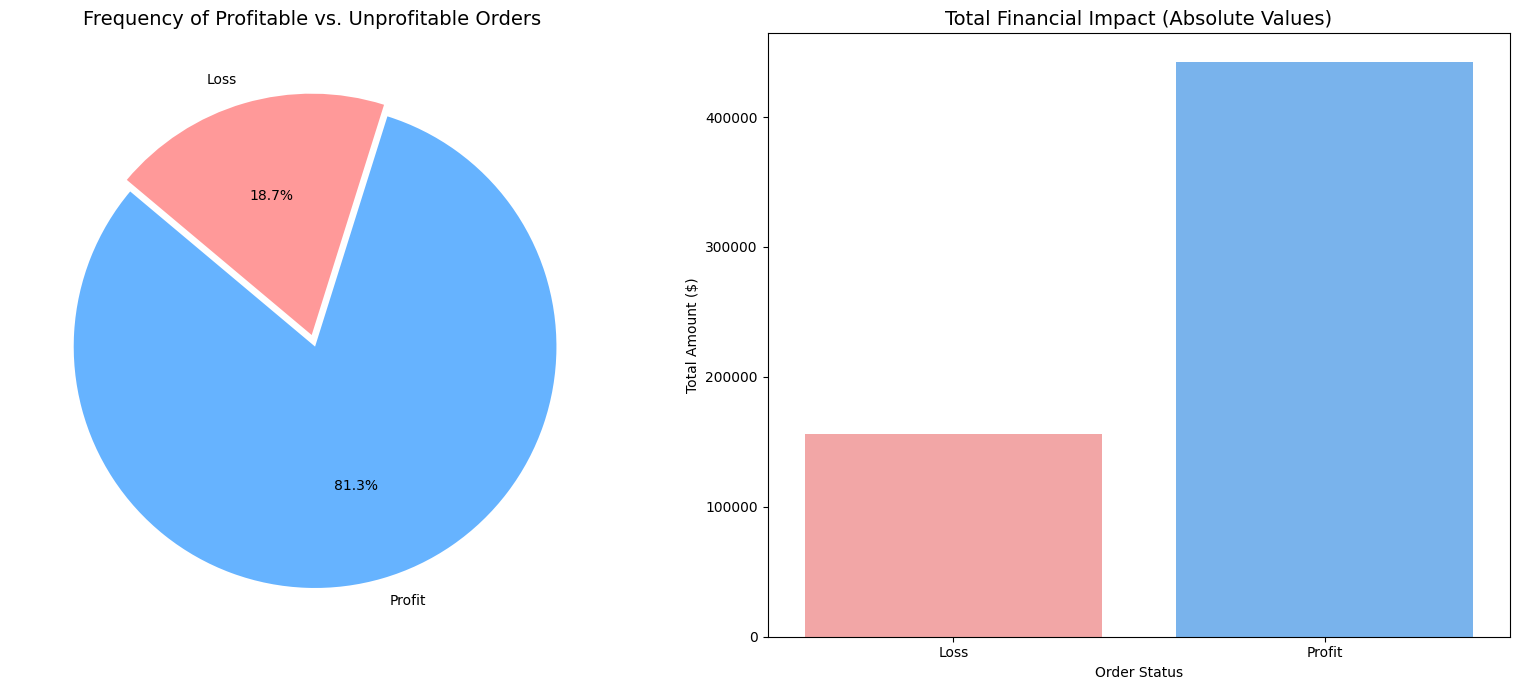

In [18]:

df['Profit_Status'] = df['Profit'].apply(lambda x: 'Profit' if x >= 0 else 'Loss')

# Set up the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Frequency Distribution (Pie Chart)
status_counts = df['Profit_Status'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            startangle=140, colors=['#66b3ff','#ff9999'], explode=(0.05, 0))
axes[0].set_title('Frequency of Profitable vs. Unprofitable Orders', fontsize=14)

# 2. Financial Impact (Total Amount)
impact_data = df.groupby('Profit_Status')['Profit'].sum().abs()
# Updated to use hue and legend=False to suppress FutureWarning
sns.barplot(x=impact_data.index, y=impact_data.values, ax=axes[1], hue=impact_data.index, palette=['#ff9999', '#66b3ff'], legend=False)
axes[1].set_title('Total Financial Impact (Absolute Values)', fontsize=14)
axes[1].set_ylabel('Total Amount ($)')
axes[1].set_xlabel('Order Status')

plt.tight_layout()
plt.show()

### Business Insights: Profit vs. Loss Comparison

*   **Order Frequency**: While ~81% of orders are profitable, the ~19% of unprofitable orders are significant.
*   **Margin Erosion**: The bar chart shows that while the total profit is higher, the absolute magnitude of losses is substantial, suggesting that a few deep-loss transactions might be significantly dragging down the overall company performance.
*   **Actionable Strategy**: The business should investigate if specific categories or regions are over-represented in the 'Loss' flag to refine pricing or discount rules.

### Summary of Profit Analysis

**Raw Profit Distribution:**
*   **Central Concentration:** Most transactions hover around zero or low profit margins, indicating a high-volume, low-margin business model.
*   **The Loss Sector:** The distribution extends into negative territory (left of the red line). These represent 'Loss Leaders' or poorly priced items where the cost of sales/discounts exceeds revenue.
*   **Extreme Outliers:** Large spikes on the far right represent high-value 'Home Run' sales, likely from Technology or specialized Corporate orders.

**Business Insights:**
*   **Risk Management:** The significant frequency of negative profit indicates a need to review the discount strategy, as deep discounts may be eroding margins entirely.
*   **Profitability Stability:** The shifted log view helps normalize the data to see the general health of the business, confirming that while outliers exist, the core business is slightly profitable but sensitive to costs.

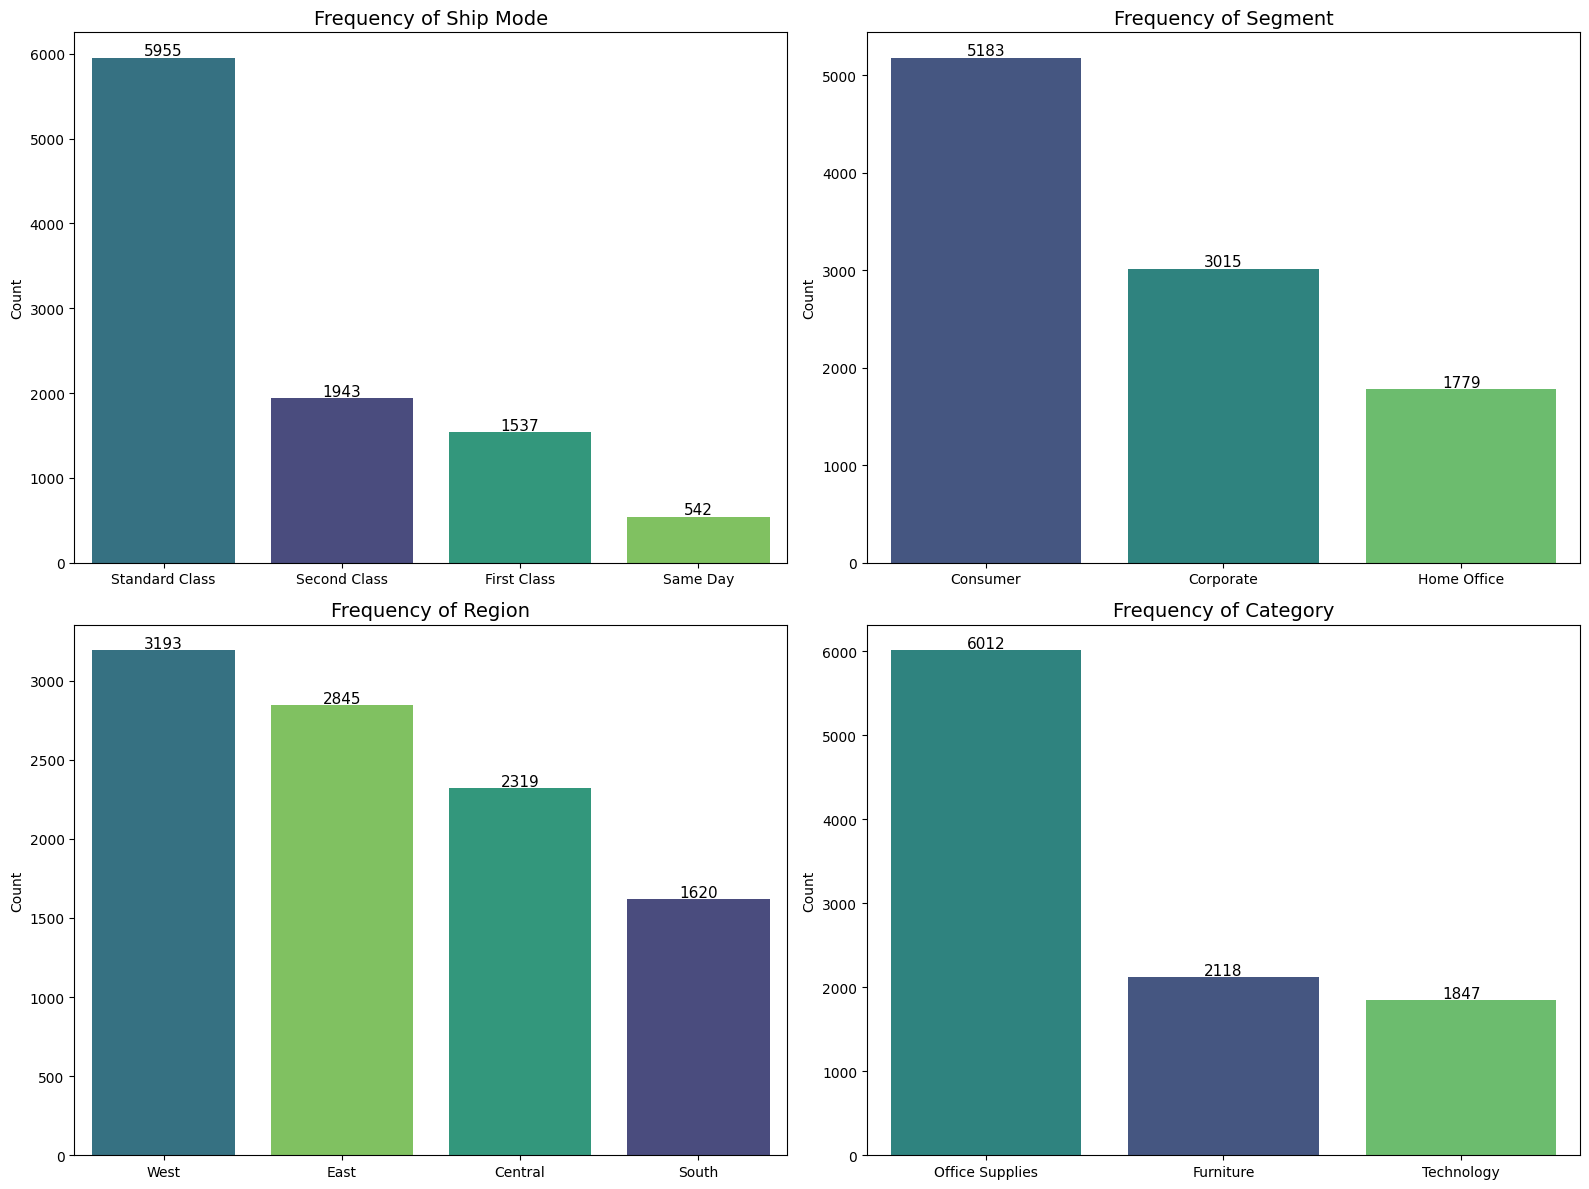

In [19]:

cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category']

# Set up the figure for multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Sort by frequency for better readability
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Frequency of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    # Add count labels on top of bars
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                         textcoords='offset points')

plt.tight_layout()
plt.show()

**Ship Mode**: 'Standard Class' is overwhelmingly the most popular choice, indicating that most customers are cost-conscious and prioritize lower shipping fees over speed.

**Segment**: The 'Consumer' segment is the largest driver of business volume, followed by Corporate and Home Office.

**Region**: Sales are relatively well-distributed, but the 'West' and 'East' regions show the highest transaction counts, suggesting stronger market penetration or demand in these coastal areas.

**Category**: 'Office Supplies' is the high-volume leader. While individual items might have lower prices than 'Technology', the shear volume of these recurring purchases provides the operational backbone of the store.


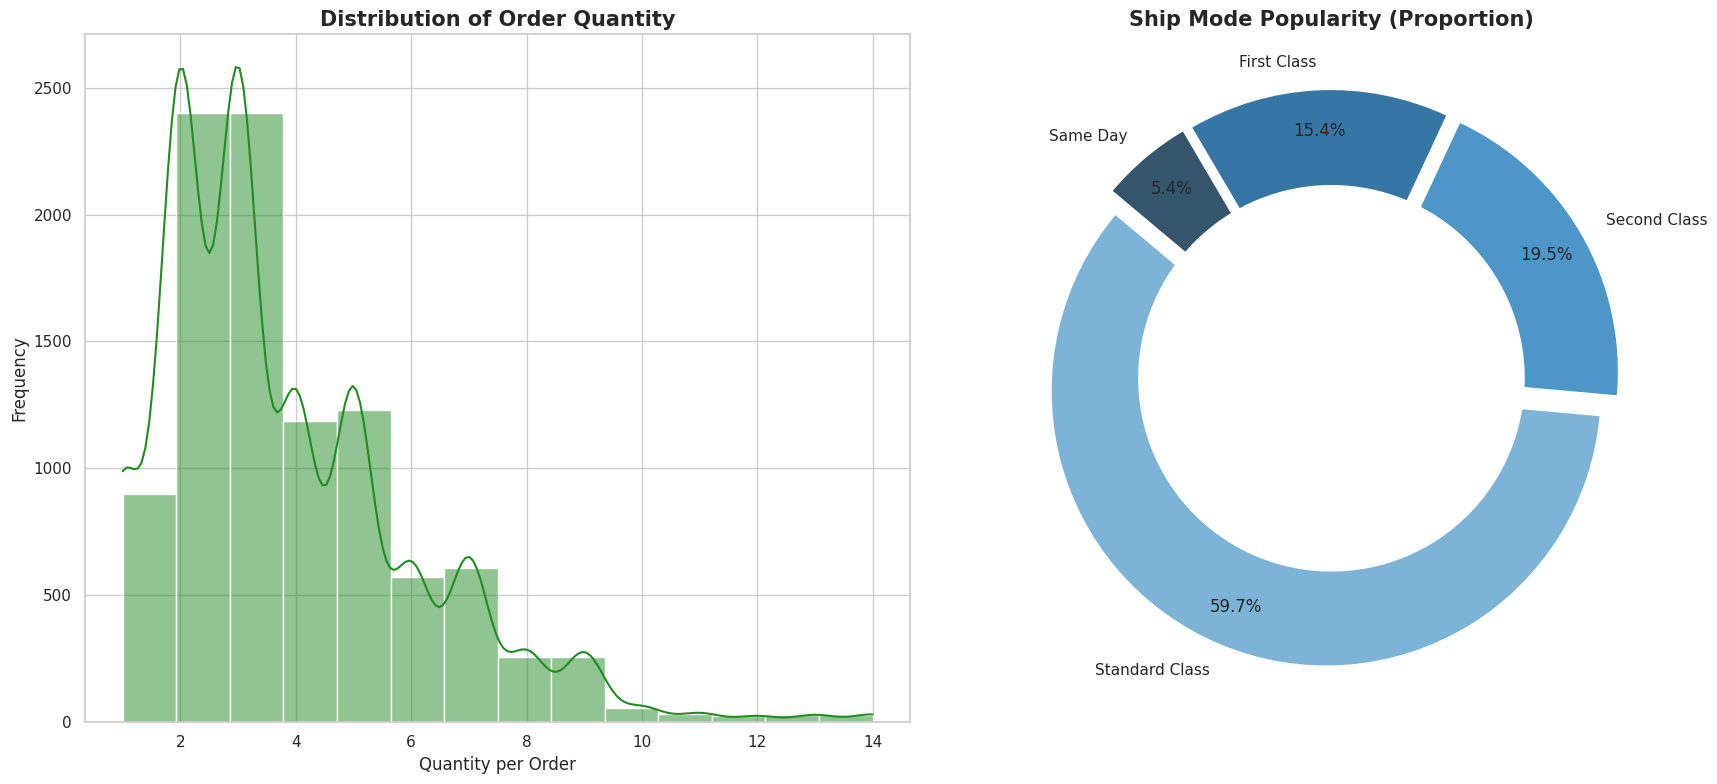

In [20]:

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Quantity Distribution
sns.histplot(df['Quantity'], bins=df['Quantity'].nunique(), kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Distribution of Order Quantity', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Quantity per Order', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# 2. Ship Mode Frequency (Donut Chart)
ship_counts = df['Ship Mode'].value_counts()
# Create a pie chart first
axes[1].pie(ship_counts, labels=ship_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Blues_d', n_colors=len(ship_counts)),
            pctdistance=0.85, explode=[0.05]*len(ship_counts))

# Add a circle at the center to transform it into a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[1].add_artist(centre_circle)

axes[1].set_title('Ship Mode Popularity (Proportion)', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()




1. Quantity Pattern: Most customers purchase items in quantities of 2 or 3. Very high quantities (above 9) are rare.
2. Shipping Strategy: The donut chart highlights that 'Standard Class' accounts for the majority of the shipping volume, confirming a high degree of price sensitivity among customers.

### Bivariate Analysis: Sales vs. Profit

We will examine the correlation between Sales and Profit to determine if higher sales consistently lead to higher profits or if certain high-value transactions are actually resulting in losses.

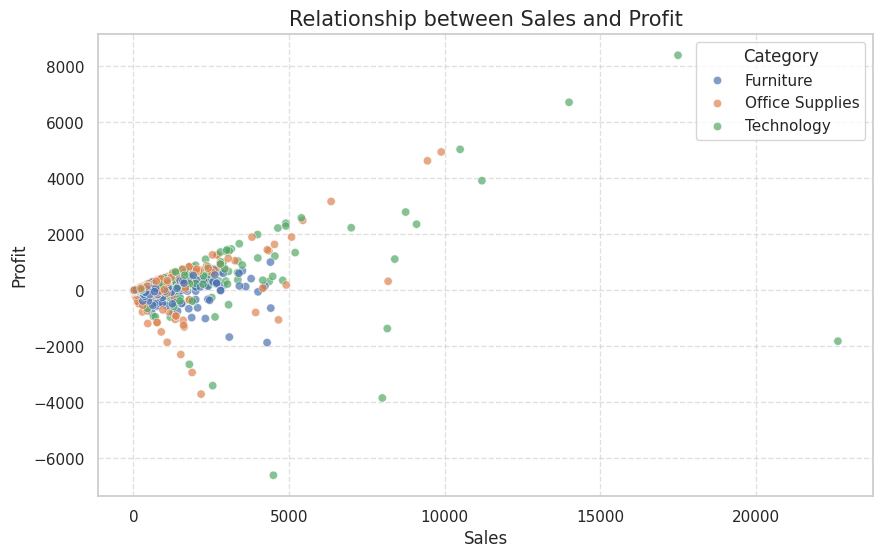

Correlation coefficient between Sales and Profit: 0.48


In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.7)
plt.title('Relationship between Sales and Profit', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation
correlation = df['Sales'].corr(df['Profit'])
print(f'Correlation coefficient between Sales and Profit: {correlation:.2f}')

Here correlation is 0.48 , so it's likely to have less corelation btween sales and profits. this means sales goes 100 percentage spike / decrease it just effects only 48 percentage of profits

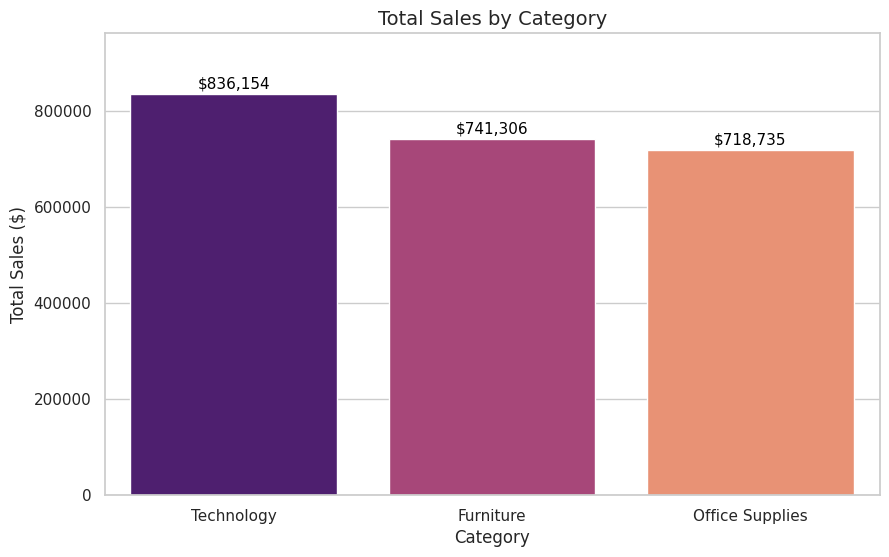

In [22]:
plt.figure(figsize=(10, 6))
sales_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
ax = sns.barplot(data=sales_cat, x='Category', y='Sales', palette='magma', hue='Category', legend=False)

# Adding data labels
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points')

plt.title('Total Sales by Category', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.ylim(0, sales_cat['Sales'].max() * 1.15) # Adjust y-limit to fit labels
plt.show()

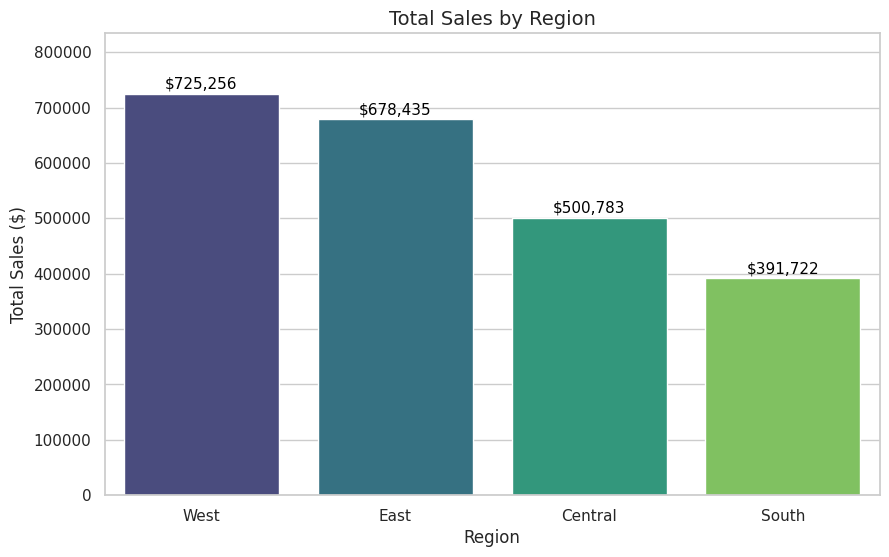

In [23]:
plt.figure(figsize=(10, 6))
sales_reg = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
ax = sns.barplot(data=sales_reg, x='Region', y='Sales', palette='viridis', hue='Region', legend=False)

# Adding data labels
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points')

plt.title('Total Sales by Region', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.ylim(0, sales_reg['Sales'].max() * 1.15) # Adjust y-limit to fit labels
plt.show()

In [24]:
df1.info()
df['Segment'].unique()

<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Region        9977 non-null   object 
 6   Category      9977 non-null   object 
 7   Sub-Category  9977 non-null   object 
 8   Sales         9977 non-null   float64
 9   Quantity      9977 non-null   int64  
 10  Discount      9977 non-null   float64
 11  Profit        9977 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 1013.3+ KB


array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

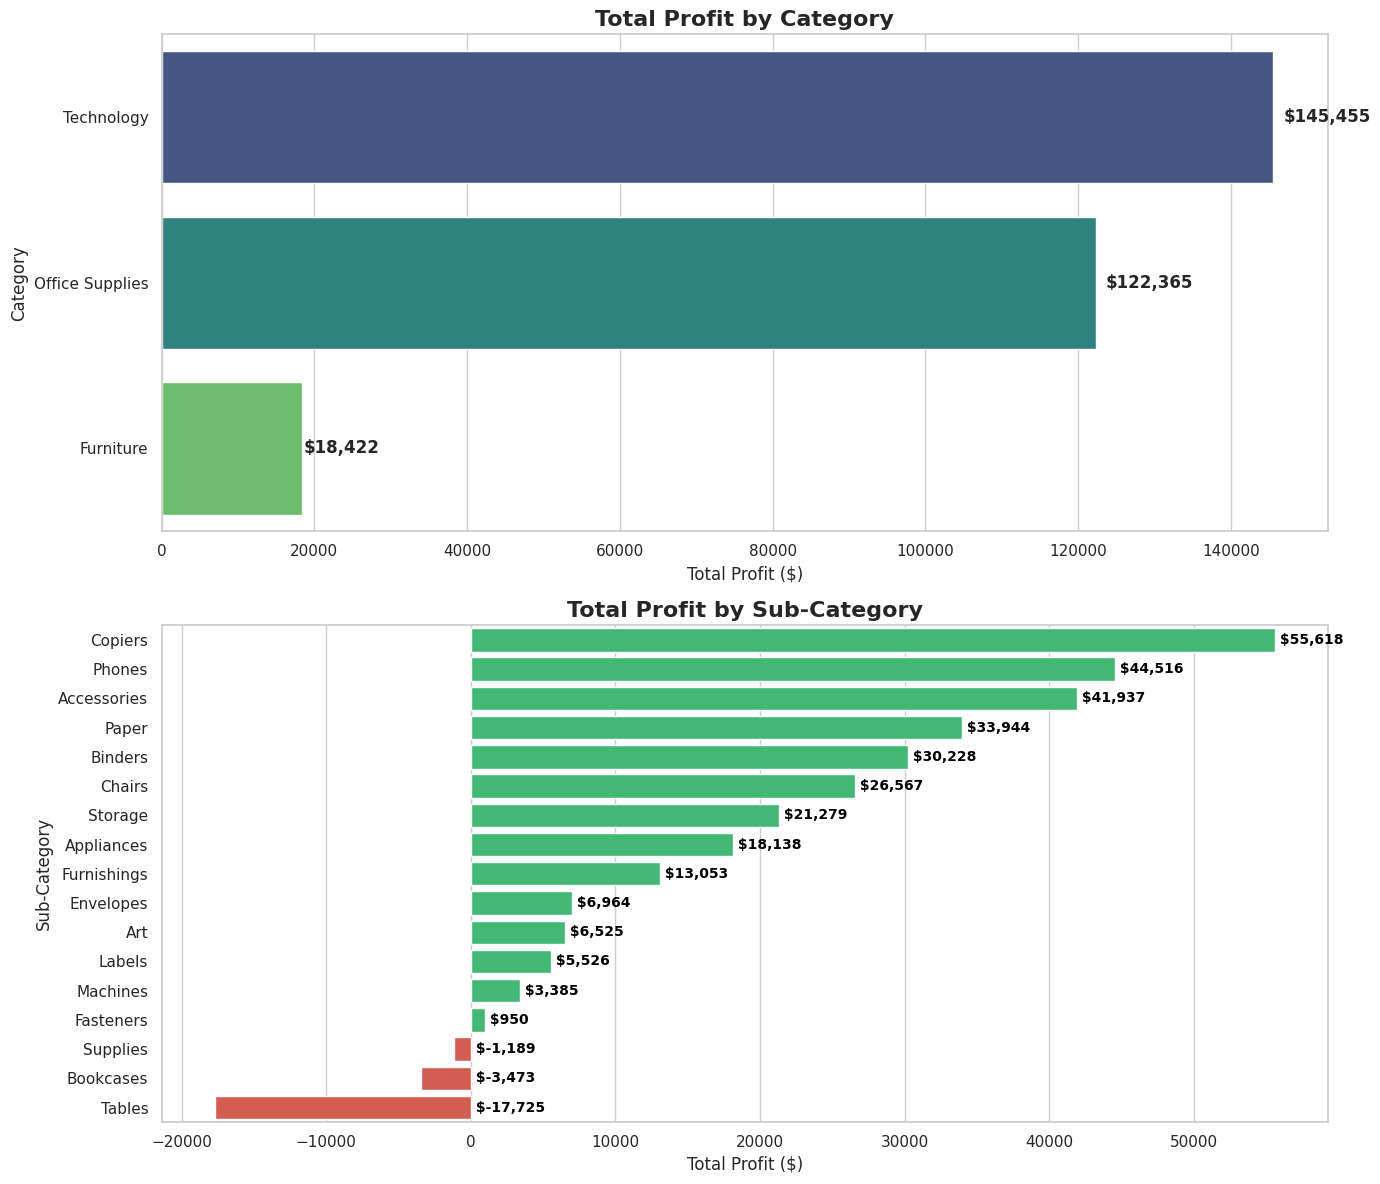

In [25]:

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Profit by Category
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_profit, x='Profit', y='Category', ax=axes[0], palette='viridis', hue='Category', legend=False)
axes[0].set_title('Total Profit by Category', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)', fontsize=12)
axes[0].set_ylabel('Category', fontsize=12)

# Adding data labels for Category
for i, v in enumerate(cat_profit['Profit']):
    axes[0].text(v + (v*0.01), i, f'${v:,.0f}', va='center', fontweight='bold')

# 2. Profit by Sub-Category
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).reset_index()
# Using a diverging palette to highlight profits vs losses
sns.barplot(data=subcat_profit, x='Profit', y='Sub-Category', ax=axes[1],
            palette=['#2ecc71' if x > 0 else '#e74c3c' for x in subcat_profit['Profit']],
            hue='Sub-Category', legend=False)
axes[1].set_title('Total Profit by Sub-Category', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)', fontsize=12)
axes[1].set_ylabel('Sub-Category', fontsize=12)

# Adding data labels for Sub-Category
for i, v in enumerate(subcat_profit['Profit']):
    axes[1].text(v if v > 0 else 0, i, f' ${v:,.0f}', va='center',
                 fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

 Profitability by Category & Sub-Category
 Critical Finding

Technology: Most profitable ($145K) with consistent margins.
Office Supplies: $122K profit, reasonable for the volume.

Furniture: Only 18Kprofiton742K revenue = 2.4% margin. Effectively a break-even category.
SUB-CATEGORY ALERTS: Tables (-17K)andBookcases( 3K) are NET LOSS sub-categories.

Machines and Supplies also show negative returns.
BEST performers: Copiers (+$55K), Phones (+$44K), Accessories (+$42K).
Action required: Reprice or discontinue Tables and Bookcases immediately.

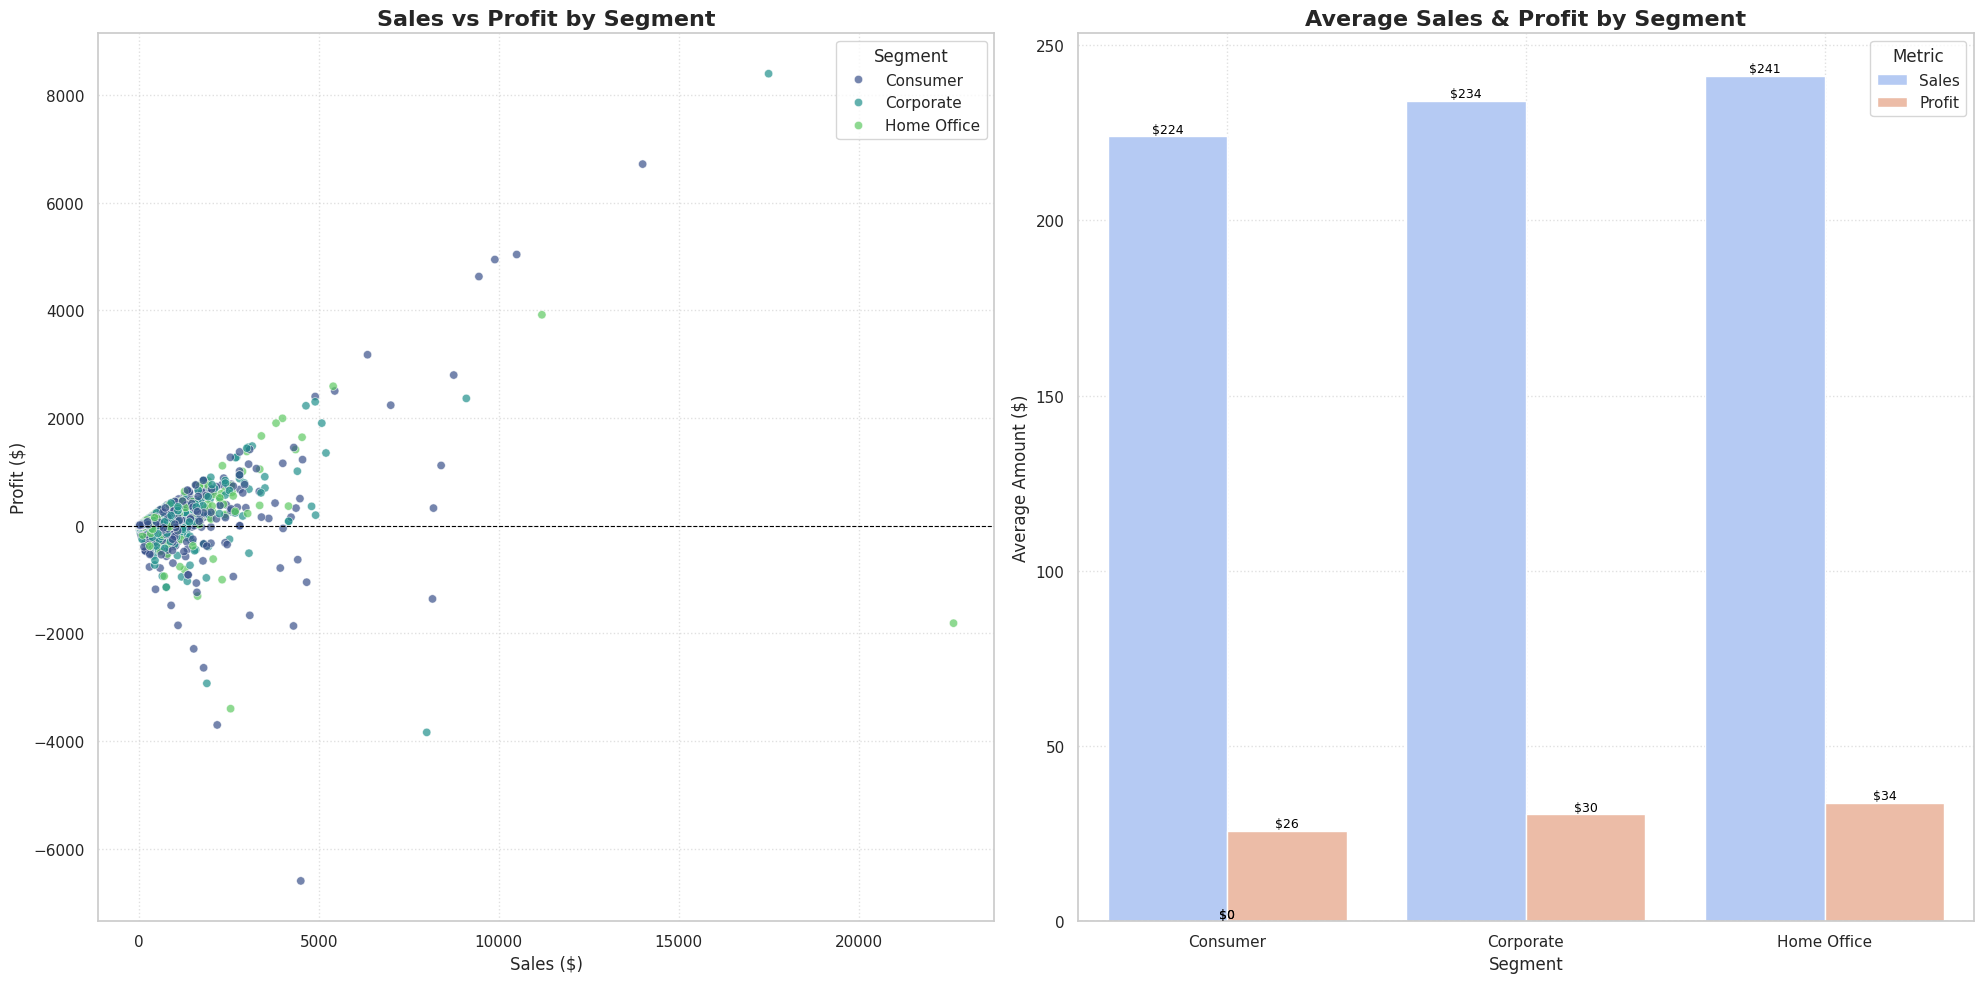

In [30]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 1. Sales vs Profit by Segment (Scatter Plot)
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Segment', ax=axes[0], alpha=0.7, palette='viridis', legend='full')
axes[0].set_title('Sales vs Profit by Segment', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Sales ($)', fontsize=12)
axes[0].set_ylabel('Profit ($)', fontsize=12)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Average Sales vs Average Profit by Segment (Bar Chart)
avg_segment_data = df.groupby('Segment')[['Sales', 'Profit']].mean().reset_index()
avg_segment_melted = avg_segment_data.melt(id_vars='Segment', var_name='Metric', value_name='Value')

sns.barplot(data=avg_segment_melted, x='Segment', y='Value', hue='Metric', ax=axes[1], palette='coolwarm')
axes[1].set_title('Average Sales & Profit by Segment', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Segment', fontsize=12)
axes[1].set_ylabel('Average Amount ($)', fontsize=12)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Add data labels for the bar chart
for p in axes[1].patches:
    axes[1].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                     textcoords='offset points')

plt.tight_layout()
plt.show()

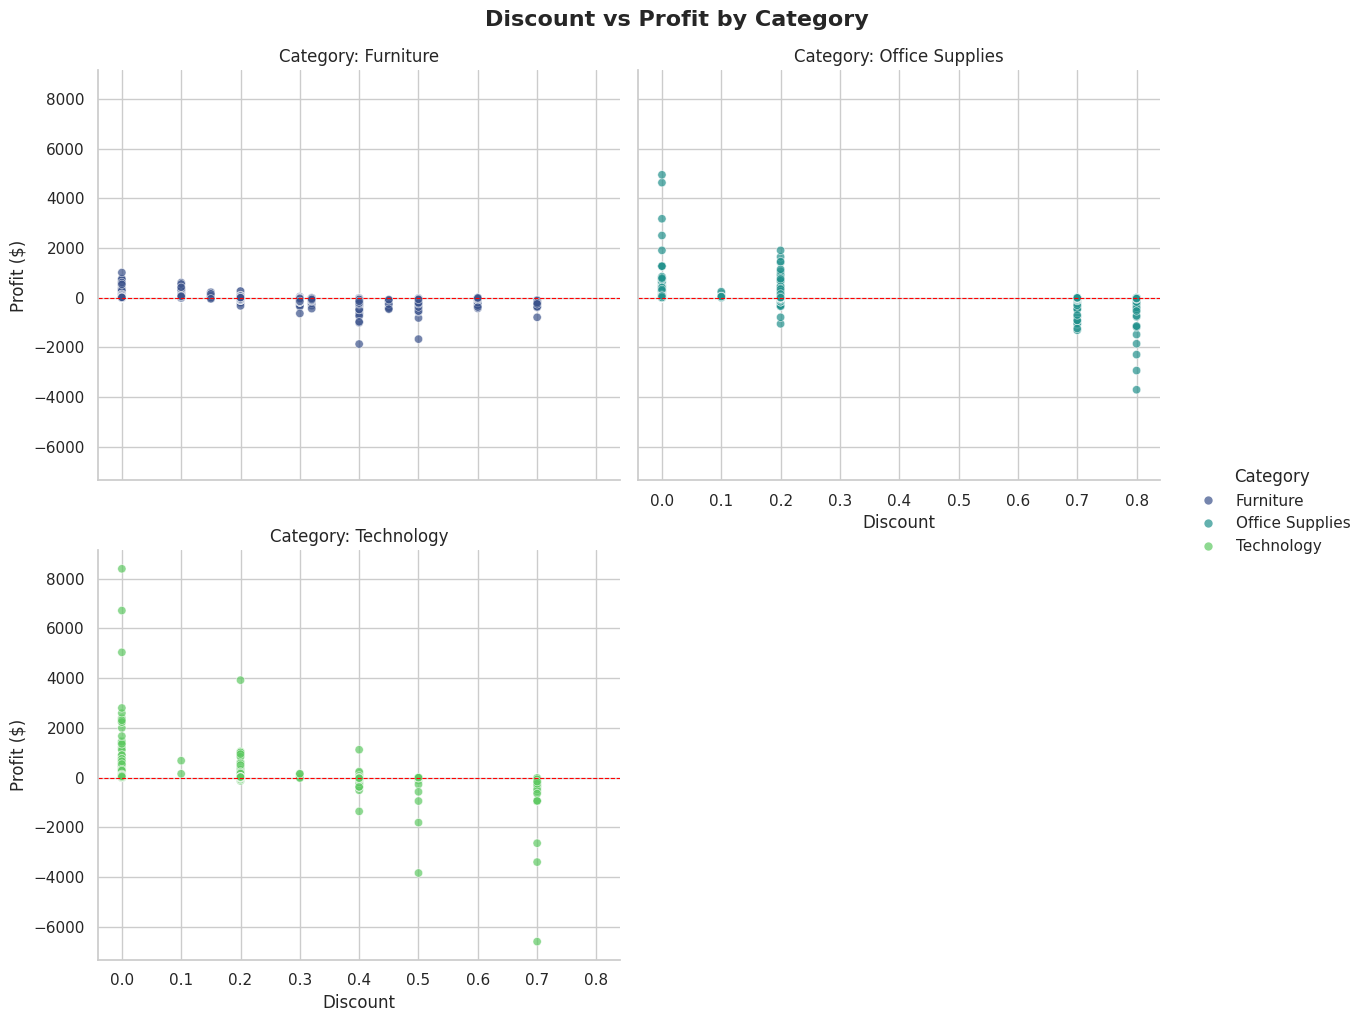

In [31]:
sns.set_theme(style='whitegrid')

# Create a relplot to show Discount vs Profit for each Category
# Using 'col' to create separate subplots for each category
g = sns.relplot(data=df, x='Discount', y='Profit', col='Category',
                hue='Category', palette='viridis', col_wrap=2, height=5, aspect=1.2, alpha=0.7)
g.set_axis_labels('Discount', 'Profit ($)')
g.set_titles('Category: {col_name}')
g.tight_layout()

# Add a horizontal line at Profit = 0 for better interpretation of losses
for ax in g.axes.flat:
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.suptitle('Discount vs Profit by Category', y=1.02, fontsize=16, fontweight='bold') # Add a main title
plt.show()

### Business Insights: Discount vs Profit by Category

This multi-panel plot clearly illustrates how discounting strategies impact profit across different product categories:

*   **Furniture**: This category is highly sensitive to discounts. Even small discounts (e.g., 0.1-0.3) can quickly drive profits into negative territory. Deep discounts (0.5 and above) almost consistently result in significant losses. This reaffirms that Furniture is a problematic category where discount policies need rigorous re-evaluation.

*   **Office Supplies**: While generally more resilient than Furniture, Office Supplies also show a clear trend of declining profit with increasing discounts. Discounts beyond 0.4 often lead to losses. However, there are some profitable transactions even at higher discount levels, indicating specific products within this category might be able to absorb more discount.

*   **Technology**: This category is the most profitable and generally withstands discounts better. While profits decrease with higher discounts, losses are less frequent and less severe compared to Furniture. High-value Technology items with minimal or no discount contribute significantly to overall profit. There are instances of losses at very high discounts (0.7-0.8), but these are rarer. The strategy here should be to protect margins on high-value items while being strategic with discounts to drive volume on others.

### Business Insights: Aggregated Profitability

**1. Total Profit by Segment:**
*   **Consumer Segment**: Dominates in total profit, indicating it's the largest and most profitable customer base. This aligns with its high transaction volume observed earlier.
*   **Corporate Segment**: Contributes significantly, showing a strong, stable profit contribution.
*   **Home Office Segment**: While smaller than Consumer and Corporate, it still shows a healthy total profit.

**2. Total Profit by Region:**
*   **West and East Regions**: Stand out as the most profitable regions, reflecting their higher transaction counts and stronger market presence. They are key drivers of overall company profit.
*   **South Region**: Provides a moderate profit contribution.
*   **Central Region**: While generating substantial sales (as seen in earlier plots), it lags behind in total profit, suggesting potential margin issues or higher operational costs in this region. This warrants further investigation to understand why sales volume isn't translating into proportional profit.

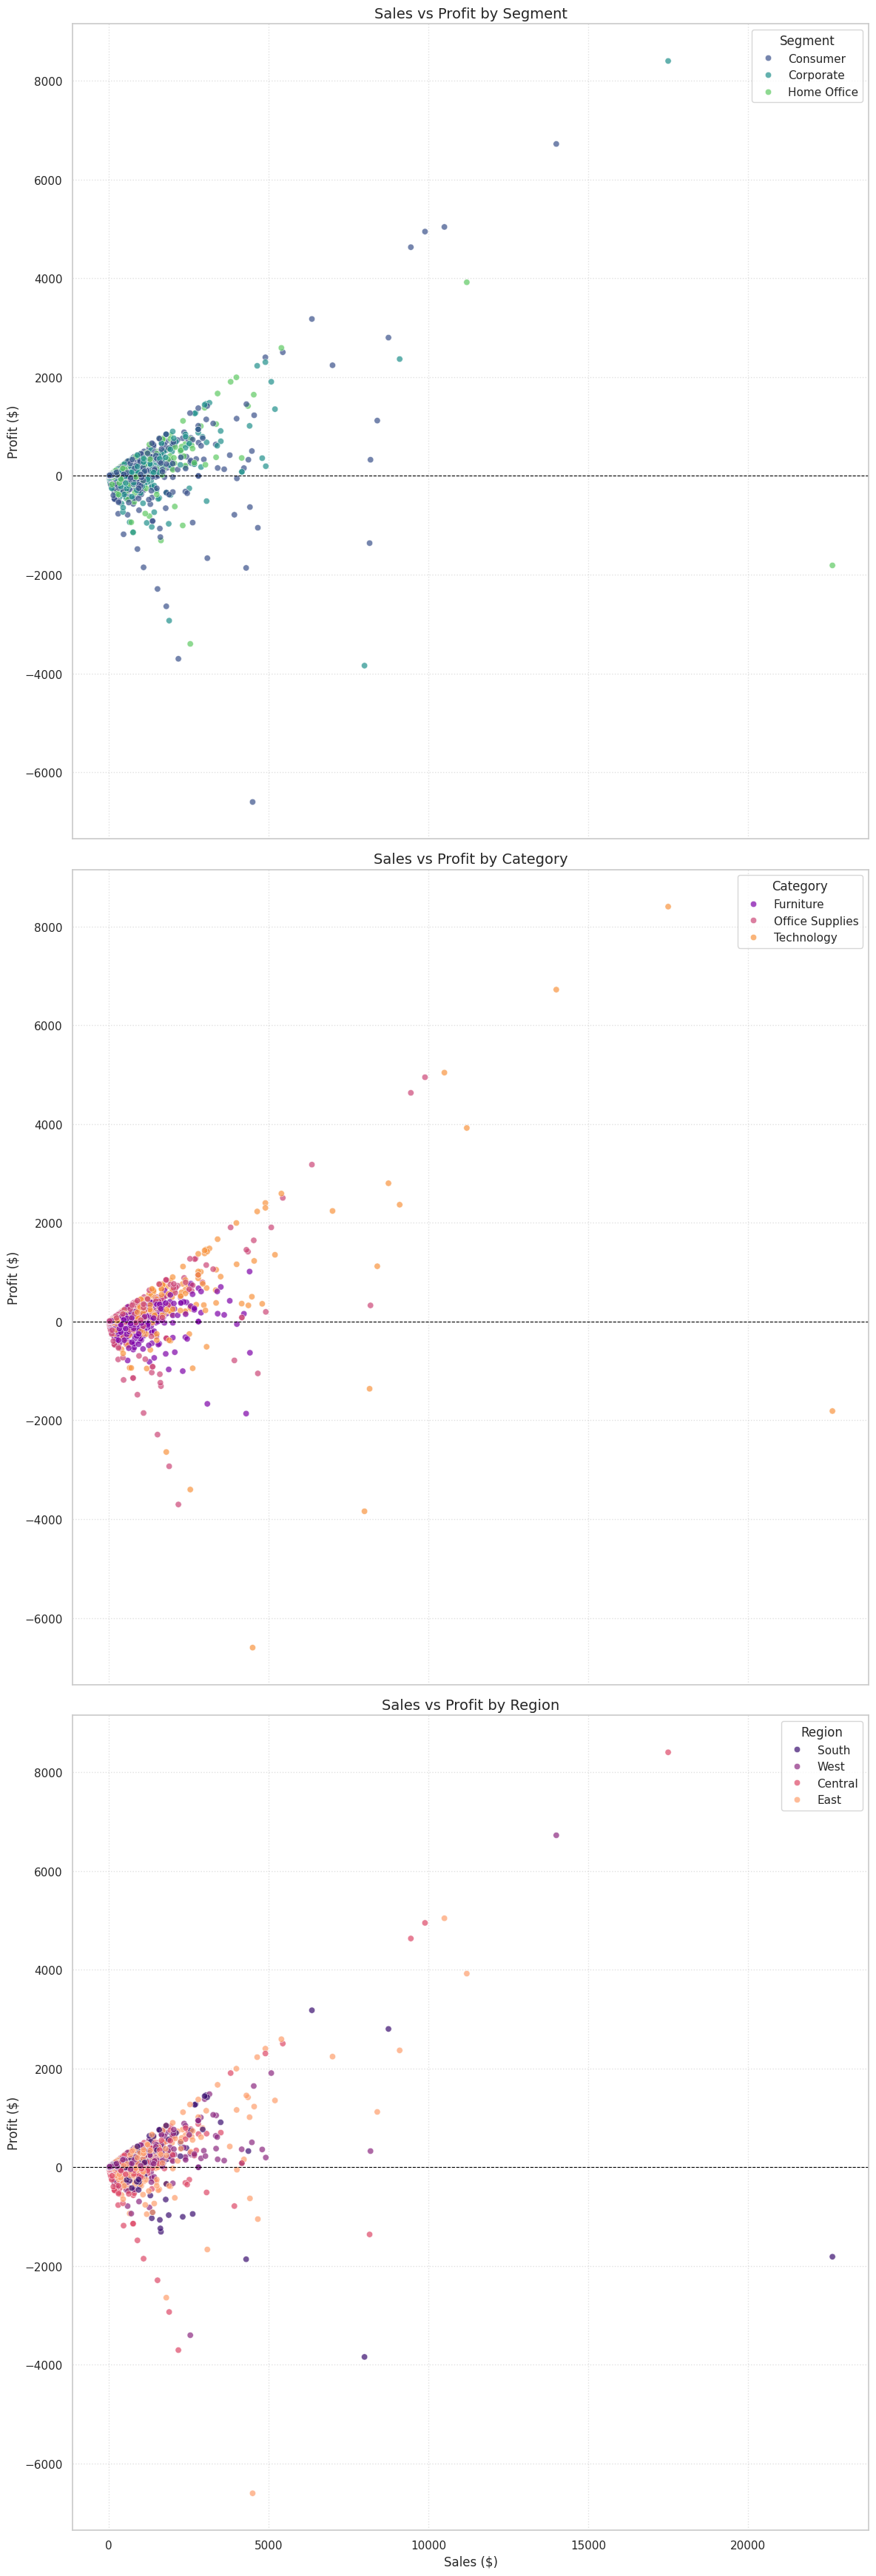

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(12, 35), sharex=True) # Changed to 3 rows, 1 column; sharing x-axis

# Sales vs Profit by Segment
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Segment', ax=axes[0], alpha=0.7, palette='viridis')
axes[0].set_title('Sales vs Profit by Segment', fontsize=14)
axes[0].set_xlabel('Sales ($)', fontsize=12)
axes[0].set_ylabel('Profit ($)', fontsize=12)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Sales vs Profit by Category
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', ax=axes[1], alpha=0.7, palette='plasma')
axes[1].set_title('Sales vs Profit by Category', fontsize=14)
axes[1].set_xlabel('Sales ($)', fontsize=12)
axes[1].set_ylabel('Profit ($)', fontsize=12) # Added y-label for clarity in vertical layout
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Sales vs Profit by Region
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Region', ax=axes[2], alpha=0.7, palette='magma')
axes[2].set_title('Sales vs Profit by Region', fontsize=14)
axes[2].set_xlabel('Sales ($)', fontsize=12)
axes[2].set_ylabel('Profit ($)', fontsize=12) # Added y-label for clarity in vertical layout
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Business Insights: Sales vs Profit Analysis

**1. Sales vs Profit by Segment:**
*   **Consumer Segment**: Shows a wide range of sales and profits, including some of the highest profitable transactions, but also significant losses, suggesting a broad customer base with varied purchasing behaviors and sensitivity to discounts.
*   **Corporate Segment**: Appears to have a more consistent profit margin, with fewer extreme losses compared to the Consumer segment, indicating more stable and predictable business.
*   **Home Office Segment**: Similar to Corporate, but with generally lower sales volumes, suggesting smaller business operations.

**2. Sales vs Profit by Category:**
*   **Technology**: Consistently generates high sales and high profits, with some transactions pushing into very high profit margins, making it a key revenue driver.
*   **Office Supplies**: Exhibits a high volume of transactions, but generally with lower individual sales and profits. It also shows a notable number of loss-making transactions, especially for higher sales values, which could be due to excessive discounting.
*   **Furniture**: Appears to be the most problematic category. While it can generate high sales, many high-sales transactions result in significant losses, confirming earlier observations about its low profitability and the impact of discounts.

**3. Sales vs Profit by Region:**
*   **West and East Regions**: These regions show the highest number of transactions and generally better overall profit performance, including the most high-profit sales. They also contain some loss-making transactions, but the overall trend is positive.
*   **Central Region**: Appears to have a balanced distribution of sales, but also a considerable number of transactions leading to losses, which might warrant further investigation into pricing or discount strategies specific to this region.
*   **South Region**: Shows fewer high-volume sales compared to West and East, and similar to Central, it experiences a mix of profitable and unprofitable transactions, requiring careful monitoring.

### Correlation Analysis: Pearson vs. Spearman

Correlation matrices help us understand the linear (Pearson) and monotonic (Spearman) relationships between numerical variables in the dataset. We'll visualize both side-by-side for a comprehensive view.

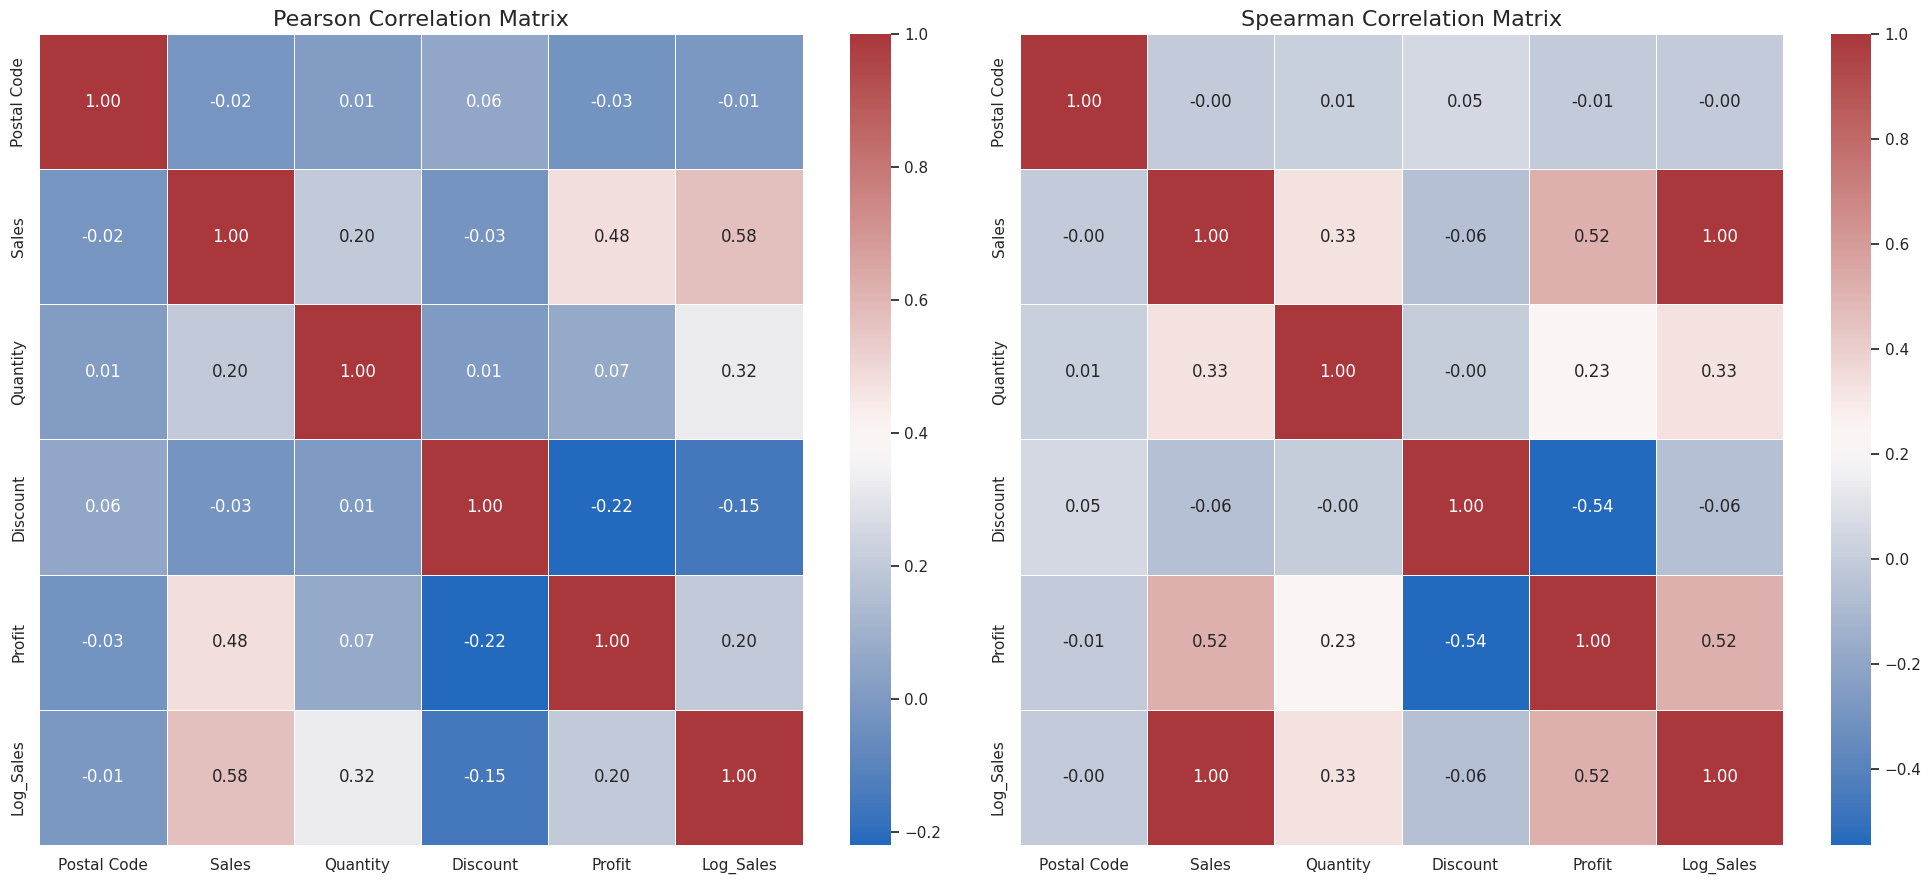

In [37]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate Pearson and Spearman Correlation Matrices
pearson_corr = numerical_df.corr(method='pearson')
spearman_corr = numerical_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 9)) # 1 row, 2 columns for side-by-side plots

# Pearson Correlation Heatmap
sns.heatmap(pearson_corr, annot=True, cmap='vlag', fmt=".2f", linewidths=.5, ax=axes[0], cbar=True)
axes[0].set_title('Pearson Correlation Matrix', fontsize=16)

# Spearman Correlation Heatmap
sns.heatmap(spearman_corr, annot=True, cmap='vlag', fmt=".2f", linewidths=.5, ax=axes[1], cbar=True)
axes[1].set_title('Spearman Correlation Matrix', fontsize=16)

plt.tight_layout()
plt.show()

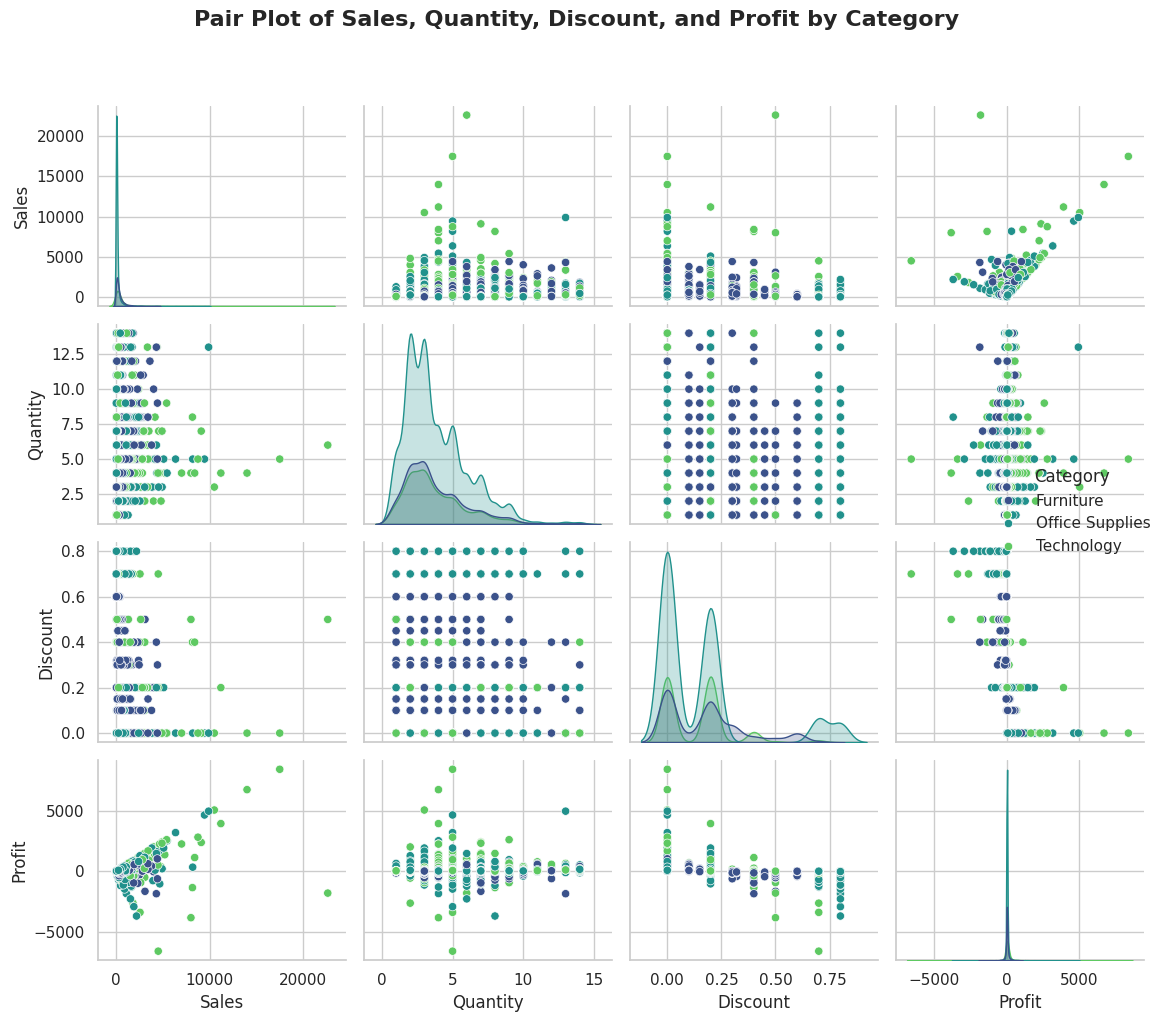

In [38]:
sns.set_theme(style='whitegrid')

# Select relevant numerical columns and one categorical column for hue
plot_df = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Category']]

# Create the pair plot
g = sns.pairplot(plot_df, hue='Category', palette='viridis', diag_kind='kde')

# Adjust title and layout
g.fig.suptitle('Pair Plot of Sales, Quantity, Discount, and Profit by Category', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### Insights from the Pair Plot

This pair plot provides a comprehensive overview of the relationships between 'Sales', 'Quantity', 'Discount', and 'Profit', with data points colored by 'Category'.

**Diagonal Plots (KDEs):**
*   **Sales**: Shows a highly right-skewed distribution across all categories, with Technology having some of the highest sales values.
*   **Quantity**: Mostly concentrated on lower quantities (2-3 items), consistent across categories.
*   **Discount**: Peaks at 0% and 0.2 (20%) discount, with other discount levels appearing less frequently.
*   **Profit**: Shows a wide distribution, with a significant number of transactions resulting in losses, especially for 'Furniture'.

**Off-Diagonal Plots (Scatter Plots):**
*   **Sales vs. Profit**: This is a crucial relationship. We can observe:
    *   **Technology**: Generally shows a positive correlation; higher sales often lead to higher profits. There are very high profit transactions here.
    *   **Office Supplies**: Most transactions are in the lower-to-mid range of sales and profit. Some losses are visible.
    *   **Furniture**: This category frequently shows negative profit, even for transactions with moderate to high sales. This highlights the vulnerability of Furniture to losses, particularly under discounts.
*   **Discount vs. Profit**: This further emphasizes the negative impact of discounts on profit:
    *   For 'Furniture', even small discounts can lead to losses, and higher discounts almost guarantee negative profit.
    *   For 'Office Supplies', discounts beyond a certain point (e.g., 0.4) often result in losses.
    *   'Technology' seems more resilient but can still incur losses with very high discounts.
*   **Quantity vs. Sales/Profit**: Generally, higher quantities correlate with higher sales, but the profit outcome still heavily depends on the category and discount applied. For example, large quantities of discounted Furniture items can lead to substantial losses.

**Overall**: The plot vividly illustrates the varying profitability profiles of different product categories and reinforces previous findings about the detrimental effect of high discounts, particularly on 'Furniture'.

### Insights from Correlation Matrices

**Pearson Correlation (Left Heatmap - Linear Relationships):**
This heatmap shows the linear correlation coefficient between pairs of numerical variables. Values range from -1 to 1:
*   **Positive Correlations (closer to 1)**: Variables increase or decrease together in a linear fashion. For example, 'Sales' and 'Profit' show a moderate positive correlation (~0.48), suggesting that generally, higher sales amounts tend to lead to higher profits, but the relationship isn't perfectly linear. 'Quantity' and 'Sales' also have a positive correlation.
*   **Negative Correlations (closer to -1)**: Variables move in opposite directions linearly. 'Discount' and 'Profit' have a negative correlation (~-0.22), which is expected: as discounts increase, profit tends to decrease.
*   **Weak/No Correlations (closer to 0)**: Indicates a weak or no linear relationship. For instance, 'Postal Code' generally shows very low correlations with other variables, as it's an identifier rather than a measure of value.

**Spearman Correlation (Right Heatmap - Monotonic Relationships):**
This heatmap illustrates the monotonic correlation coefficient. It assesses whether variables tend to increase or decrease together, regardless of whether the relationship is strictly linear.
*   **Robustness to Outliers**: Spearman correlation is less sensitive to outliers and non-linear but monotonic relationships compared to Pearson. If the relationship between variables is consistently increasing or decreasing but not in a straight line, Spearman might show a stronger correlation.
*   **Similar to Pearson**: For many pairs (e.g., 'Sales' and 'Profit', 'Discount' and 'Profit'), the Spearman correlation values are quite similar to Pearson. This suggests that the relationships are reasonably linear or at least strongly monotonic.
*   **Key Differences**: If you observe a significant difference between Pearson and Spearman for a pair, it often implies a strong monotonic relationship that isn't perfectly linear, or the presence of outliers skewing the Pearson result. In this dataset, the trends are largely consistent across both measures, reinforcing the observed relationships.

### Project Summary: Key Business Insights (10 Points)

1.  **Data Quality**: The dataset is structurally clean with no missing values and duplicates were successfully removed, ensuring reliability of analysis.
2.  **Overall Profitability & Losses**: An overall profit margin of ~12.5% is observed, but ~18.7% of orders result in losses, indicating significant areas for profit optimization.
3.  **Outliers are Business Realities**: Extreme sales and profit/loss values (outliers) were retained as they represent actual business transactions, such as massive tech orders or deep losses from heavily discounted furniture, providing crucial context for strategic decisions.
4.  **Sales Distribution**: Sales are heavily right-skewed, meaning most transactions are small, with a few high-value sales driving a significant portion of revenue.
5.  **Profit Distribution**: Profitability is bimodal, with many small positive profits but also a substantial number of transactions generating significant losses, especially large ones.
6.  **Category Performance**: 'Technology' is the most profitable category. 'Office Supplies' drives high volume. 'Furniture' is a problematic category, often leading to losses despite high sales.
7.  **Sub-Category Alert**: 'Tables' and 'Bookcases' are identified as consistent net loss sub-categories, requiring immediate re-evaluation of pricing or discontinuation.
8.  **Impact of Discounts**: Discounts above 20% (and especially above 40%) consistently lead to negative profit margins across most categories, severely eroding overall profitability.
9.  **Regional Performance**: 'West' and 'East' regions are the strongest performers in both sales and profit. The 'Central' region shows high sales but lower profitability, suggesting potential operational inefficiencies or localized pricing issues.
10. **Strategic Imperatives**: Review discounting policies, particularly for 'Furniture' and 'Office Supplies'. Investigate the 'Central' region's profitability and potentially re-evaluate 'Tables' and 'Bookcases' product lines.